## 1. Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Load Data

In [2]:
df = pd.read_csv("../data/cleaned_laptop_data.csv")
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (1174, 21)


,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,...,CPU_speed,CPU_core,Resolution_X,Resolution_Y,Pixel_Count,SSD,HDD,GPU_brand,Company_match,avg_brand_spec_rating
0,apple,ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,intel iris plus graphics 640,macos,1.37,...,2.3,i5,2560.0,1600.0,4096000.0,128.0,0.0,intel,apple,66.750000
1,apple,ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,intel hd graphics 6000,macos,1.34,...,1.8,i5,1440.0,900.0,1296000.0,0.0,0.0,intel,apple,66.750000
2,hp,notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,intel hd graphics 620,no os,1.86,...,2.5,i5,1920.0,1080.0,2073600.0,256.0,0.0,intel,hp,69.425373
3,apple,ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,amd radeon pro 455,macos,1.83,...,2.7,i7,2880.0,1800.0,5184000.0,512.0,0.0,amd,apple,66.750000
4,apple,ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,intel iris plus graphics 650,macos,1.37,...,3.1,i5,2560.0,1600.0,4096000.0,256.0,0.0,intel,apple,66.750000


## 3. Advanced Feature Extraction


In [3]:
# Modern Screen Features
# Note: Resolution_X and Resolution_Y already exist in cleaned_laptop_data.csv
df['Touchscreen'] = df['ScreenResolution'].apply(lambda x: 1 if 'Touchscreen' in x else 0)
df['IPS'] = df['ScreenResolution'].apply(lambda x: 1 if 'IPS' in x else 0)
df['is_4K'] = df['ScreenResolution'].apply(lambda x: 1 if '4K Ultra HD' in x or '3840x2160' in x else 0)

# Inches should be numeric for PPI calculation
df['Inches'] = pd.to_numeric(df['Inches'], errors='coerce')

# Re-calculate PPI using existing resolution columns
df['PPI'] = (((df['Resolution_X']**2) + (df['Resolution_Y']**2))**0.5 / df['Inches']).astype('float')

# CPU Tiering (Ranking performance) 
def get_cpu_tier(cpu):
    cpu = str(cpu).lower()
    if 'i9' in cpu or 'xeon' in cpu or 'ryzen 9' in cpu: return 5
    if 'i7' in cpu or 'ryzen 7' in cpu: return 4
    if 'i5' in cpu or 'ryzen 5' in cpu: return 3
    if 'i3' in cpu or 'ryzen 3' in cpu: return 2
    if 'celeron' in cpu or 'pentium' in cpu or 'atom' in cpu: return 0
    return 1 # Default mid-low category

df['CPU_Tier'] = df['Cpu'].apply(get_cpu_tier)

# GPU Classification (Discrete vs Integrated) 
def get_gpu_type(gpu):
    gpu = str(gpu).lower()
    # Keywords indicating a dedicated high-performance GPU
    discrete_keywords = ['gtx', 'rtx', 'quadro', 'radeon pro', 'radeon rx', 'firepro', 'm1000', 'm1200', 'm2000', 'm2200']
    for word in discrete_keywords:
        if word in gpu: return 1 
    return 0

df['Is_Discrete_GPU'] = df['Gpu'].apply(get_gpu_type)

# Storage Features
# Using original SSD and HDD columns directly
df['Has_SSD'] = (df['SSD'] > 0).astype(int)

# Performance Score 
# Higher score indicates better hardware combination
df['Performance_Score'] = (df['CPU_Tier'] * df['CPU_speed']) + (df['Ram'] * 0.5) + (df['Is_Discrete_GPU'] * 2)

# Target Transformation
df['Log_Price'] = np.log(df['Price'])

# Rare Label Encoding for Company
company_counts = df['Company'].value_counts()
rare_companies = company_counts[company_counts < 10].index
df['Company'] = df['Company'].apply(lambda x: 'Other' if x in rare_companies else x)

df[['Touchscreen', 'IPS', 'is_4K', 'PPI', 'CPU_Tier', 'Is_Discrete_GPU', 'SSD', 'HDD', 'Performance_Score', 'Log_Price']].head()

,Touchscreen,IPS,is_4K,PPI,CPU_Tier,Is_Discrete_GPU,SSD,HDD,Performance_Score,Log_Price
0,0,1,0,226.983005,3,0,128.0,0.0,10.9,11.175755
1,0,0,0,127.677940,3,0,0.0,0.0,9.4,10.776777
2,0,0,0,141.211998,3,0,256.0,0.0,11.5,10.329931
3,0,1,0,220.534624,4,1,512.0,0.0,20.8,11.814476
4,0,1,0,226.983005,3,0,256.0,0.0,13.3,11.473101


## 3.1 Visualizing Performance Score Assumptions

The Performance_Score is a feature designed to capture the interactions between the CPU, RAM, and GPU. We assign higher weights to the CPU Tier and Discrete GPU presence, while adding the raw RAM capacity. This assumes that a laptop's value is non-linearly driven by the combination of its core components.

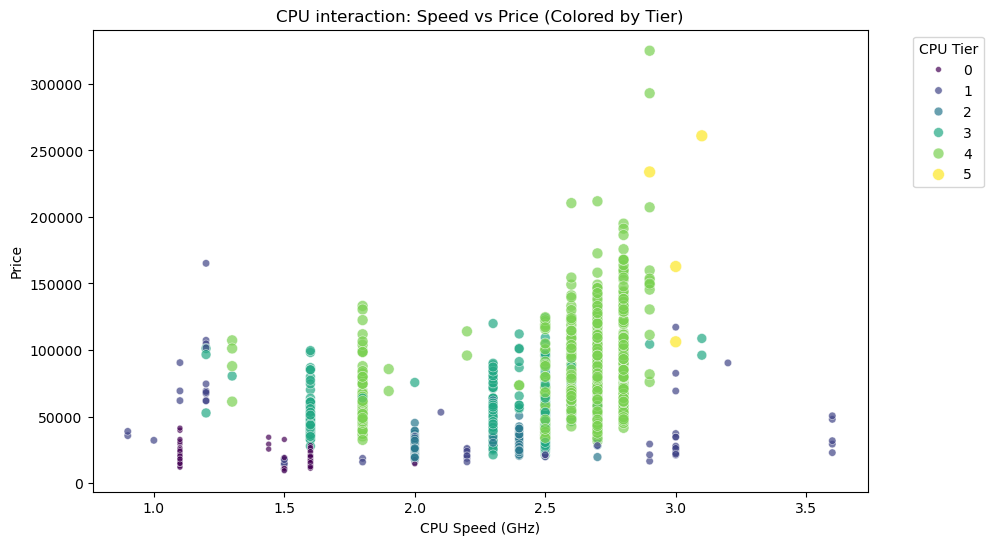

In [4]:
# CPU Interaction Effect (Tier x Speed)
# Assumption: High-tier CPUs at high speeds result in exponential price increases.
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CPU_speed', y='Price', hue='CPU_Tier', size='CPU_Tier', palette='viridis', data=df, alpha=0.7)
plt.title("CPU interaction: Speed vs Price (Colored by Tier)")
plt.xlabel("CPU Speed (GHz)")
plt.ylabel("Price")
plt.legend(title='CPU Tier', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

The graph above plots the interaction effort (CPU Tier x CPU Speed) against Price. It can be seen that lower tiers that have high speed are cheaper than higher tiers that have high speed. Laptops equipped with "Tier 4" processors represent the bulk of the dataset. Interestingly, they span a wide price range even at similar speeds (ex. at 2.8 GHz), suggesting that other factors like GPU or build quality are driving the price variations within this tier. There isn't a simple linear "higher speed = higher price" rule. For example, some processors at 3.5 GHz (Tiers 1 and 2) are significantly cheaper than those at 2.8 GHz (Tiers 4 and 5), indicating that architecture and "Tier" rank are better predictors of cost than speed alone.

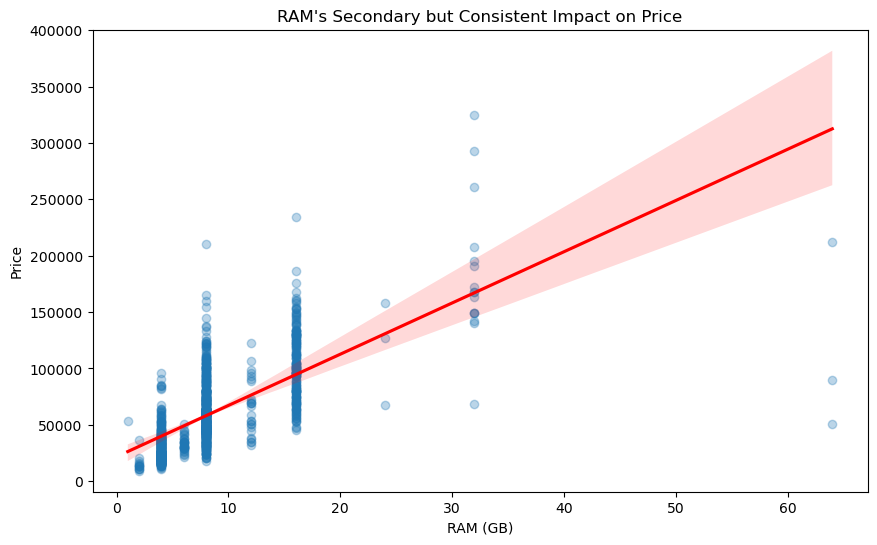

In [5]:
# RAM vs Price
# Assumption: RAM has a steady linear correlation with price, justifying its secondary weight (0.5).
plt.figure(figsize=(10, 6))
sns.regplot(x='Ram', y='Price', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title("RAM's Secondary but Consistent Impact on Price")
plt.xlabel("RAM (GB)")
plt.ylabel("Price")
plt.show()

It can be seem that there is low variance at low RAM and high variance at high RAM. At 4GB and 8GB, the price range is very tight, while once you hit 32GB or 64GB, the "confidence interval" (the shaded red area) widens significantly. This tells us that while high RAM usually means a high price, other premium features (like a high-end GPU) start to vary the price more wildly at the top end. This is why RAM was scaled down in the performance score equation.

/var/folders/rb/rg8v17fx7nn0n6l9qg4rsgth0000gn/T/ipykernel_8679/2739150074.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Is_Discrete_GPU', y='Price', data=df, palette='Set2')


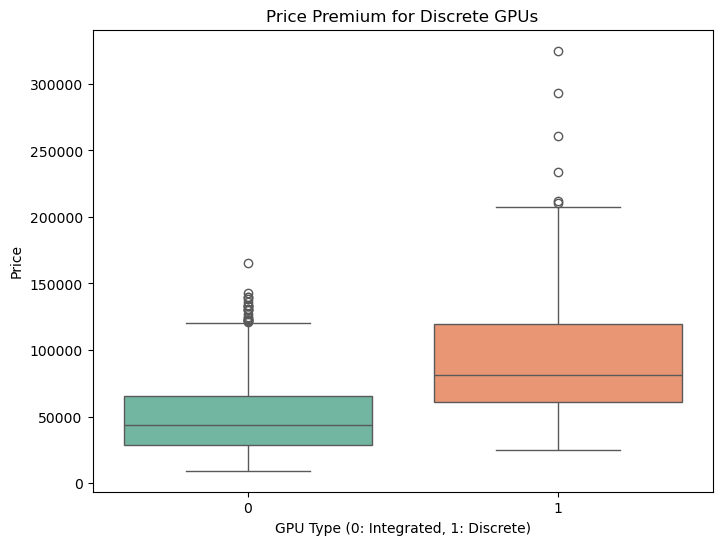

In [6]:
# GPU Type Impact
# Assumption: Discrete GPUs significantly shift the price distribution upward.
plt.figure(figsize=(8, 6))
sns.boxplot(x='Is_Discrete_GPU', y='Price', data=df, palette='Set2')
plt.title("Price Premium for Discrete GPUs")
plt.xlabel("GPU Type (0: Integrated, 1: Discrete)")
plt.ylabel("Price")
plt.show()

This boxplot compares the price distribution between laptops with Integrated GPUs (0) and Discrete GPUs (1). It clearly illustrates the "price premium" associated with dedicated graphics hardware. The median price for discrete GPUs is significantly higher than that for integrated ones. This suggests that simply switching from an integrated chip to a discrete card roughly doubles the "typical" price of the laptop. Discrete GPU laptops have a much larger Interquartile Range, meaning there is a huge variety in price for gaming laptops compared to office laptops. While both categories have outliers, the discrete category has outliers reaching above 300,000. These likely represent gaming laptops where the GPU cost alone might exceed the price of a standard laptop. Even the lowest-priced discrete GPU laptops start at a higher price floor than the lowest-priced integrated laptops. There is almost no "budget" category for discrete graphics. Therefore, it makes sense to weight GPU Type the heaviest in the performance score feature.

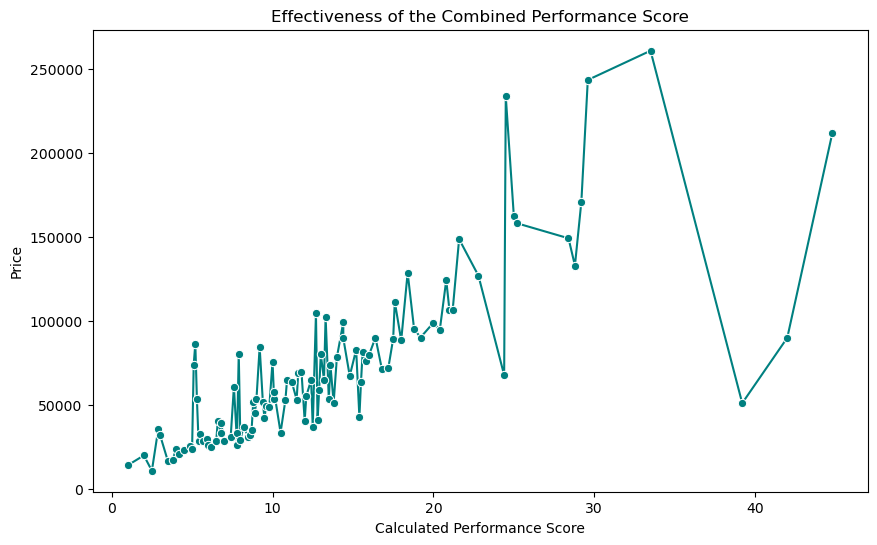

Correlation between Performance_Score and Price: 0.7574


In [7]:
# Final Performance Score vs Price
# Demonstrating that the interaction feature is a strong predictor
plt.figure(figsize=(10, 6))
sns.lineplot(x='Performance_Score', y='Price', data=df, marker='o', errorbar=None, color='teal')
plt.title("Effectiveness of the Combined Performance Score")
plt.xlabel("Calculated Performance Score")
plt.ylabel("Price")
plt.show()

corr = df['Performance_Score'].corr(df['Price'])
print(f"Correlation between Performance_Score and Price: {corr:.4f}")

## 4. Categorical Encoding & Dimensionality Reduction

In [8]:
# Group Operating Systems into larger logical categories
def group_os(os):
    os = str(os).lower()
    if 'windows' in os: return 'Windows'
    if 'mac' in os or 'macos' in os: return 'Mac'
    if 'linux' in os: return 'Linux'
    if 'no os' in os: return 'No OS'
    return 'Other'

df['OS_Category'] = df['OpSys'].apply(group_os)

# One-Hot Encoding for Categorical Variables
categorical_cols = ['Company', 'TypeName', 'OS_Category', 'CPU_core', 'GPU_brand']
df_engineered = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Drop redundant, unparsed, or raw columns that are now captured in new features
cols_to_drop = [
    'ScreenResolution', 'Cpu', 'Memory', 'Gpu', 'OpSys', 'Price', 
    'Resolution_X', 'Resolution_Y', 'Pixel_Count', 'Company_match'
]
df_drop = df_engineered.drop(columns=cols_to_drop)

print(f"Final Engineered Shape: {df_drop.shape}")
df_drop.head()

Final Engineered Shape: (1174, 46)


,Inches,Ram,Weight,CPU_speed,SSD,HDD,avg_brand_spec_rating,Touchscreen,IPS,is_4K,...,CPU_core_amd_a9,CPU_core_amd_e,CPU_core_amd_fx,CPU_core_i3,CPU_core_i5,CPU_core_i7,CPU_core_other,GPU_brand_intel,GPU_brand_nvidia,GPU_brand_other
0,13.3,8,1.37,2.3,128.0,0.0,66.750000,0,1,0,...,False,False,False,False,True,False,False,True,False,False
1,13.3,8,1.34,1.8,0.0,0.0,66.750000,0,0,0,...,False,False,False,False,True,False,False,True,False,False
2,15.6,8,1.86,2.5,256.0,0.0,69.425373,0,0,0,...,False,False,False,False,True,False,False,True,False,False
3,15.4,16,1.83,2.7,512.0,0.0,66.750000,0,1,0,...,False,False,False,False,False,True,False,False,False,False
4,13.3,8,1.37,3.1,256.0,0.0,66.750000,0,1,0,...,False,False,False,False,True,False,False,True,False,False


## 5. Train-Test Split

In [9]:
# Separate features (X) from target (y)
X = df_drop.drop(columns=['Log_Price'])
y = df_drop['Log_Price']

# 80% Training & 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (939, 45)
X_test shape: (235, 45)


## 6. Standard Scaling

In [10]:
# Select numerical features for scaling (excluding boolean/binary dummies)
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

scaler = StandardScaler()

# Fit on training data and transform both sets
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train[numeric_cols].head()

,Inches,Ram,Weight,CPU_speed,SSD,HDD,avg_brand_spec_rating,Touchscreen,IPS,is_4K,PPI,CPU_Tier,Is_Discrete_GPU,Has_SSD,Performance_Score
861,1.100701,-0.098328,0.783981,-0.046804,-0.304533,1.084534,0.197890,-0.415072,1.590621,-0.19085,-0.424941,0.051143,1.740702,0.727541,0.165347
260,1.100701,-0.098328,0.845846,-1.067934,-1.001511,3.006255,-0.598961,-0.415072,-0.628685,-0.19085,-0.424941,0.865103,-0.574481,-1.374493,-0.124764
594,-0.625029,1.396899,-1.208083,0.770099,1.786399,-0.837187,-0.598961,-0.415072,1.590621,-0.19085,0.270182,0.865103,-0.574481,0.727541,1.172202
184,1.100701,-0.098328,0.474654,-1.067934,0.392444,-0.837187,0.197890,-0.415072,-0.628685,-0.19085,-0.424941,0.865103,-0.574481,0.727541,-0.124764
643,0.211688,-0.098328,0.548892,0.361647,-1.001511,1.084534,-0.122234,-0.415072,-0.628685,-0.19085,-0.103575,0.051143,1.740702,-1.374493,0.267739


## 7. Correlation Analysis

We use a heatmap to identify which features have the most significant impact on the target variable Log_Price and to check for multi-collinearity.

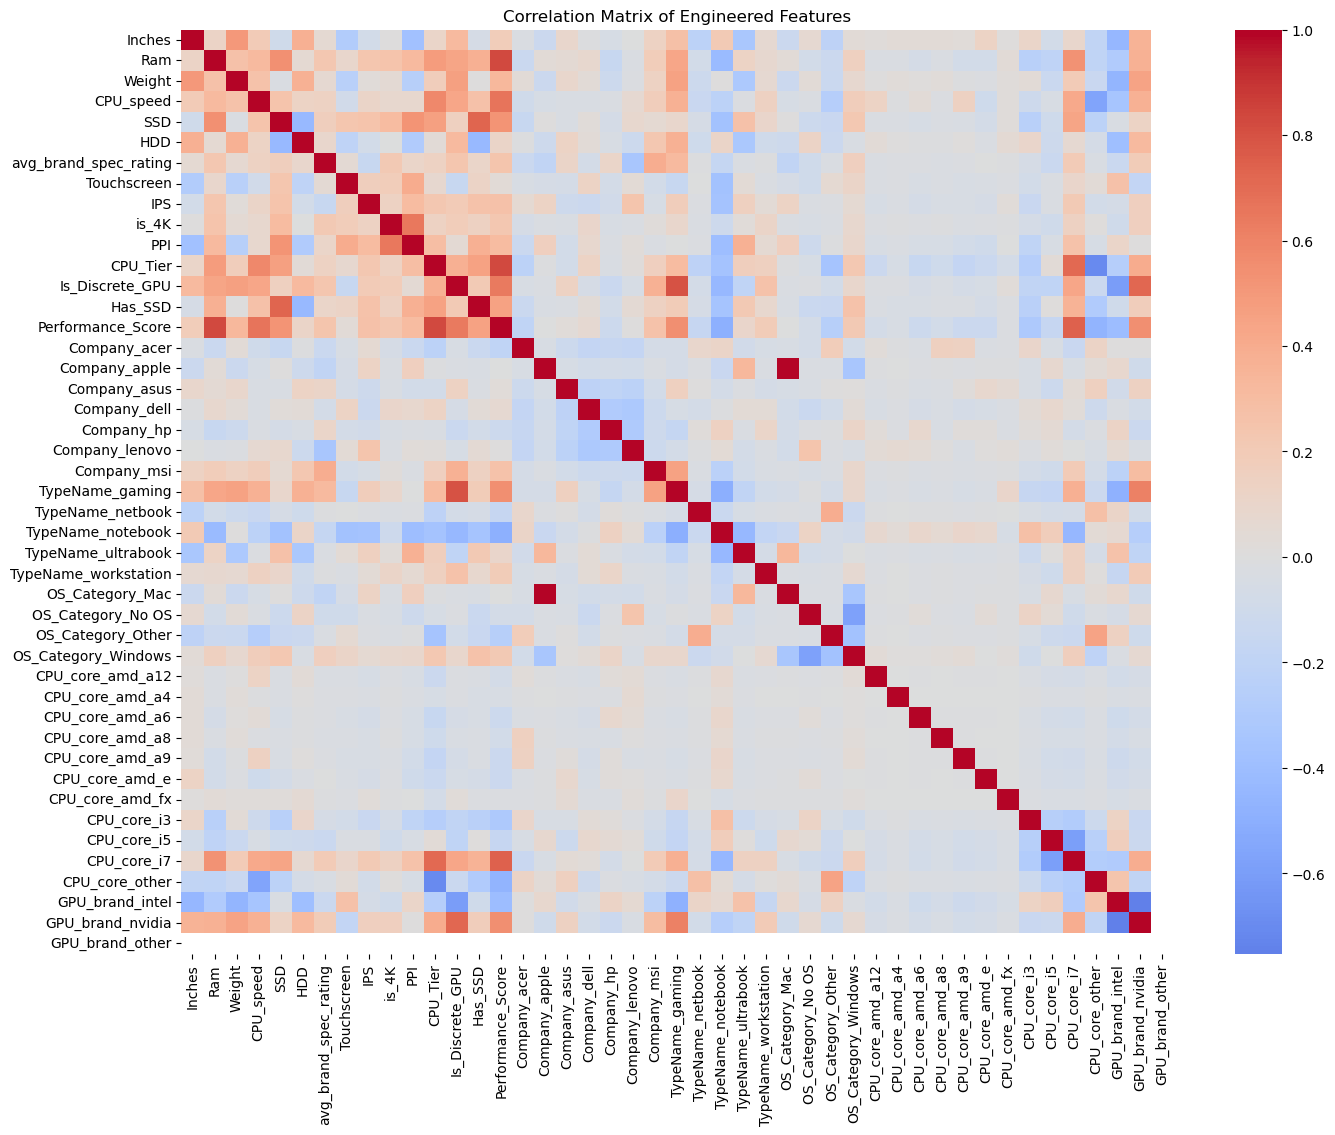

In [11]:
plt.figure(figsize=(16, 12))
correlation_matrix = X_train.corr(numeric_only=True)
sns.heatmap(
    correlation_matrix, 
    cmap="coolwarm", 
    center=0,
    annot=False
)
plt.title("Correlation Matrix of Engineered Features")
plt.show()

This confirms that the Performance_Score is effectively capturing overall hardware capability, as it is strongly aligned with its component features. It also shows that higher-end laptops tend to have better specs across multiple dimensions simultaneously. SSD and HDD exhibit a negative correlation, suggesting that laptops typically favor one primary storage type rather than both. PPI, Resolution_X, Resolution_Y, and is_4K show positive relationships, indicating that higher resolution screens tend to have higher pixel density. IPS and Touchscreen show weaker correlations, suggesting they are more independent design features. Is_Discrete_GPU is positively correlated with Performance_Score and other high-performance indicators. This aligns with earlier findings (boxplot) that discrete GPUs are associated with higher-end, more expensive laptops. Company, CPU type, GPU brand, and OS category features show low correlations with most numerical variables, indicating they provide distinct categorical information. Some features, especially within performance-related groups (e.g., CPU_Tier, CPU_speed, Performance_Score), are moderately to highly correlated. This could affect linear models by inflating variance, though tree-based models are generally robust to this.